# Prédiction d'Approbation de Prêts avec Machine Learning

## Objectif
Prédire si un prêt sera approuvé ou refusé en fonction des caractéristiques du demandeur en utilisant le dataset **loan-approval-prediction-dataset** de Kaggle.

### Dataset Source
- **Source Kaggle**: architsharma01/loan-approval-prediction-dataset
- **Variables principales**: Revenus annuels, montant du prêt, score de crédit, durée du prêt, actifs immobiliers/commerciaux, etc.
- **Variable cible**: loan_status (Approved / Rejected)

## 1. Installation et Imports - Bibliothèques Nécessaires

In [2]:
# Installation des bibliothèques nécessaires
import subprocess
import sys

# Installer kagglehub si nécessaire
try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])
    import kagglehub

# Imports principaux
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, classification_report, confusion_matrix, 
                             roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
import joblib

# Configuration des styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

print("✓ Toutes les bibliothèques sont importées avec succès!")

✓ Toutes les bibliothèques sont importées avec succès!


## 2. Téléchargement du Dataset avec KaggleHub

In [3]:
# Télécharger la dernière version du dataset depuis Kaggle
import os

try:
    path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")
    print("✓ Dataset téléchargé avec succès!")
    print(f"Chemin du dataset: {path}")
    
    # Lister les fichiers disponibles
    files = os.listdir(path)
    print(f"\nFichiers disponibles:")
    for file in files:
        print(f"  - {file}")
except Exception as e:
    print(f"⚠️ Erreur lors du téléchargement: {e}")
    print("Utilisation du fichier local disponible...")
    path = "."

100%|██████████| 80.6k/80.6k [00:00<00:00, 412kB/s]

Extracting files...
✓ Dataset téléchargé avec succès!
Chemin du dataset: C:\Users\ACER\.cache\kagglehub\datasets\architsharma01\loan-approval-prediction-dataset\versions\1

Fichiers disponibles:
  - loan_approval_dataset.csv


## 3. Chargement du CSV et Inspection Rapide

In [4]:
# Charger le dataset
csv_file = os.path.join(path, "loan_approval_dataset.csv")
df = pd.read_csv(csv_file)

print("=" * 80)
print("INSPECTION DU DATASET")
print("=" * 80)

# Dimensions
print(f"\n📊 Dimensions du dataset:")
print(f"   Shape: {df.shape}")
print(f"   Nombre de lignes: {df.shape[0]}")
print(f"   Nombre de colonnes: {df.shape[1]}")

# Premières lignes
print(f"\n📋 Premières lignes du dataset:")
print(df.head(10))

# Types de données et infos complètes
print(f"\n🔍 Types de données:")
print(df.dtypes)

print(f"\n📋 Informations détaillées du dataset:")
print(df.info())

# Informations détaillées
print(f"\n📈 Statistiques descriptives:")
print(df.describe())

# Vérifier les valeurs manquantes
print(f"\n❓ Valeurs manquantes:")
print(df.isnull().sum())

INSPECTION DU DATASET

📊 Dimensions du dataset:
   Shape: (4269, 13)
   Nombre de lignes: 4269
   Nombre de colonnes: 13

📋 Premières lignes du dataset:
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   
5        6                  0       Graduate            Yes        4800000   
6        7                  5       Graduate             No        8700000   
7        8                  2       Graduate            Yes        5700000   
8        9                  0       Graduate            Yes         800000   
9       10                  5   Not Graduate             No        

## 4. Nettoyage des Colonnes et des Valeurs Catégorielles

In [5]:
# Créer une copie pour le nettoyage
df_clean = df.copy()

print("🧹 ÉTAPE 1: Nettoyage des noms de colonnes")
# Nettoyer les noms de colonnes (trim et lowercasecase)
df_clean.columns = df_clean.columns.str.strip().str.lower()
print(f"Colonnes nettoyées: {list(df_clean.columns)}")

print("\n🧹 ÉTAPE 2: Nettoyage des espaces dans les valeurs texte")
# Identifier les colonnes objets (texte)
text_columns = df_clean.select_dtypes(include=['object']).columns
for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()
    print(f"  ✓ Colonne '{col}' nettoyée")

print("\n🧹 ÉTAPE 3: Vérifier les valeurs aberrantes")
# Vérifier s'il y a des valeurs négatives dans les actifs
asset_columns = [col for col in df_clean.columns if 'assets' in col or 'asset' in col]
for col in asset_columns:
    negative_count = (df_clean[col] < 0).sum()
    if negative_count > 0:
        print(f"  ⚠️ {col}: {negative_count} valeurs négatives trouvées")
        df_clean[col] = df_clean[col].clip(lower=0)  # Remplacer par 0
    else:
        print(f"  ✓ {col}: Pas de valeurs négatives")

print("\n🧹 ÉTAPE 4: Résumé final du nettoyage")
print(f"Dataset après nettoyage: {df_clean.shape}")
print(f"Valeurs manquantes restantes: {df_clean.isnull().sum().sum()}")
print("✓ Nettoyage terminé avec succès!")

🧹 ÉTAPE 1: Nettoyage des noms de colonnes
Colonnes nettoyées: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

🧹 ÉTAPE 2: Nettoyage des espaces dans les valeurs texte
  ✓ Colonne 'education' nettoyée
  ✓ Colonne 'self_employed' nettoyée
  ✓ Colonne 'loan_status' nettoyée

🧹 ÉTAPE 3: Vérifier les valeurs aberrantes
  ⚠️ residential_assets_value: 28 valeurs négatives trouvées
  ✓ commercial_assets_value: Pas de valeurs négatives
  ✓ luxury_assets_value: Pas de valeurs négatives
  ✓ bank_asset_value: Pas de valeurs négatives

🧹 ÉTAPE 4: Résumé final du nettoyage
Dataset après nettoyage: (4269, 13)
Valeurs manquantes restantes: 0
✓ Nettoyage terminé avec succès!


## 5. Analyse Exploratoire - Focus sur la Variable Cible

ANALYSE EXPLORATOIRE - VARIABLE CIBLE: loan_status

📊 Distribution de loan_status:
  Approved: 2656 (62.2%)
  Rejected: 1613 (37.8%)


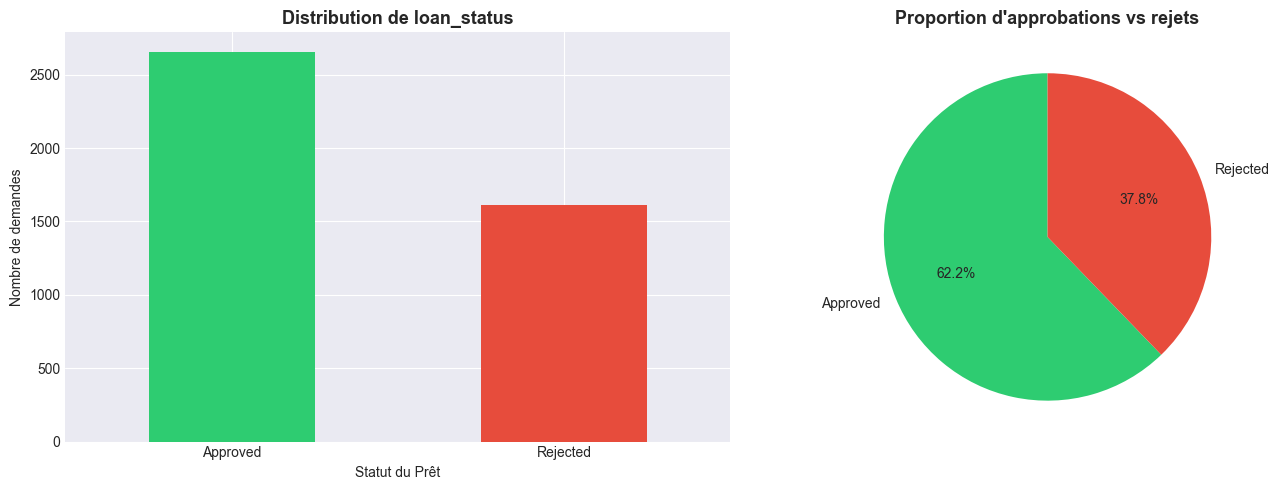


RELATIONS ENTRE VARIABLES CLÉS ET LA CIBLE


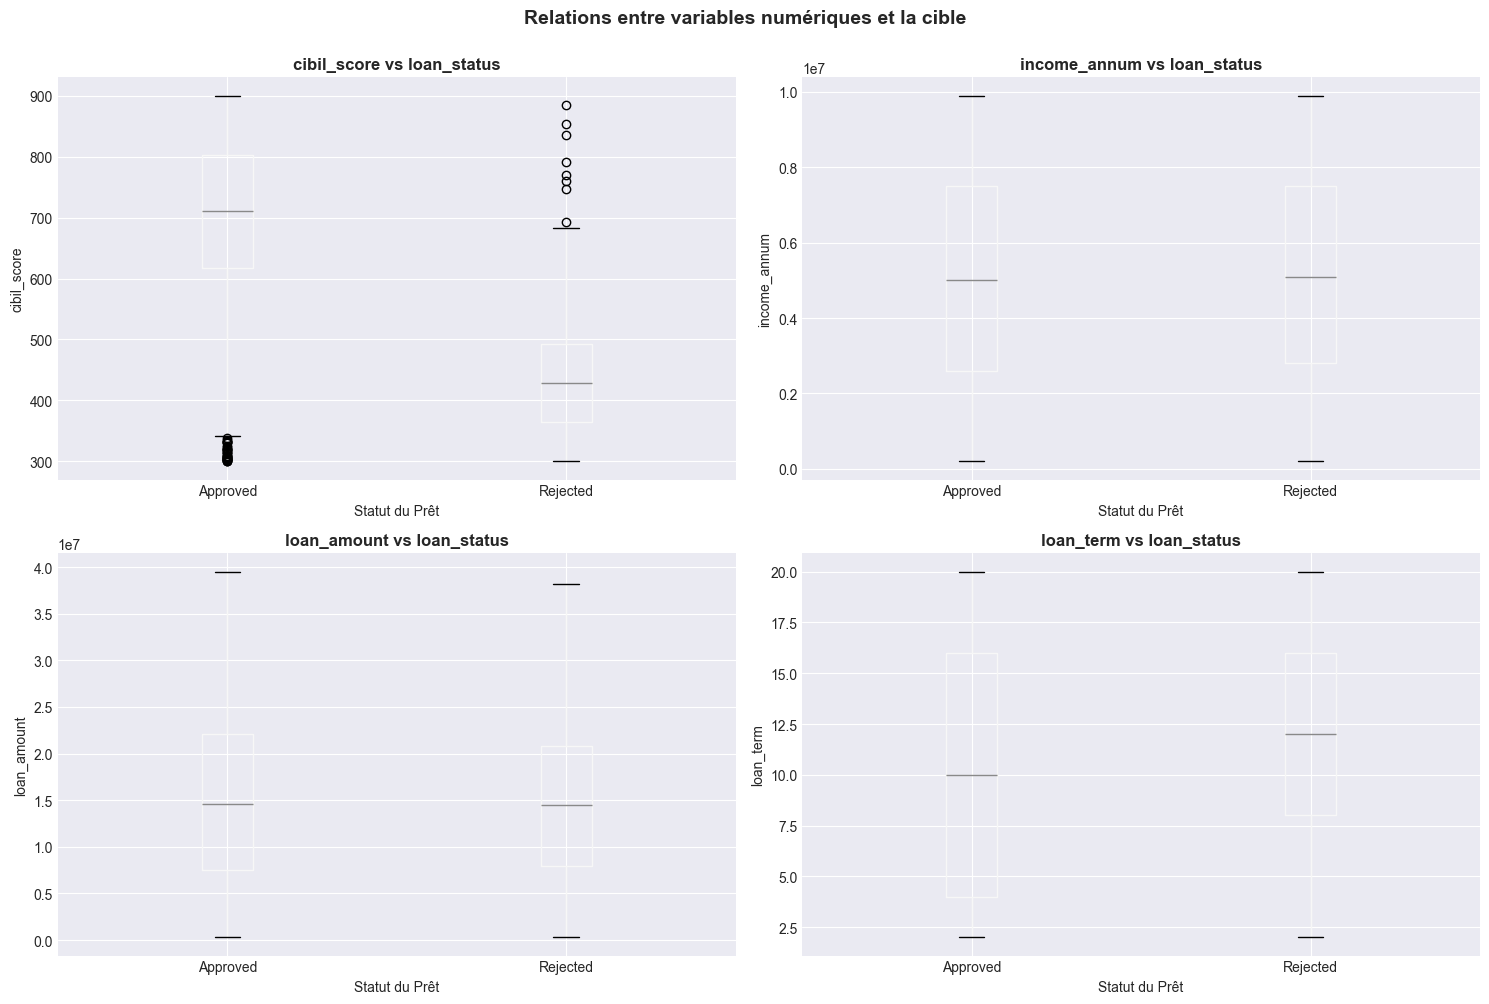


📈 Statistiques des variables clés par statut de prêt:

cibil_score:
              count        mean         std    min    25%    50%    75%    max
loan_status                                                                   
Approved     2656.0  703.461973  125.249016  300.0  618.0  711.0  803.0  900.0
Rejected     1613.0  429.468072   78.401752  300.0  364.0  429.0  493.0  885.0

income_annum:
              count          mean           std       min        25%  \
loan_status                                                            
Approved     2656.0  5.025904e+06  2.827228e+06  200000.0  2600000.0   
Rejected     1613.0  5.113825e+06  2.772946e+06  200000.0  2800000.0   

                   50%        75%        max  
loan_status                                   
Approved     5000000.0  7500000.0  9900000.0  
Rejected     5100000.0  7500000.0  9900000.0  

loan_amount:
              count          mean           std       min        25%  \
loan_status                          

In [6]:
# Analyse de la variable cible
print("=" * 80)
print("ANALYSE EXPLORATOIRE - VARIABLE CIBLE: loan_status")
print("=" * 80)

# Distribution de loan_status
target_dist = df_clean['loan_status'].value_counts()
target_pct = df_clean['loan_status'].value_counts(normalize=True) * 100

print(f"\n📊 Distribution de loan_status:")
for status, count in target_dist.items():
    pct = (count / len(df_clean)) * 100
    print(f"  {status}: {count} ({pct:.1f}%)")

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
target_dist.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution de loan_status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Statut du Prêt')
axes[0].set_ylabel('Nombre de demandes')
axes[0].tick_params(axis='x', rotation=0)

# Diagramme circulaire
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_dist.values, labels=target_dist.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Proportion d\'approbations vs rejets', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("RELATIONS ENTRE VARIABLES CLÉS ET LA CIBLE")
print("=" * 80)

# Variables numériques clés
key_numeric_cols = ['cibil_score', 'income_annum', 'loan_amount', 'loan_term']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric_cols):
    # Boxplot
    df_clean.boxplot(column=col, by='loan_status', ax=axes[idx])
    axes[idx].set_title(f'{col} vs loan_status', fontweight='bold')
    axes[idx].set_xlabel('Statut du Prêt')
    axes[idx].set_ylabel(col)
    plt.sca(axes[idx])
    plt.xticks(rotation=0)

plt.suptitle('Relations entre variables numériques et la cible', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Statistiques par groupe
print(f"\n📈 Statistiques des variables clés par statut de prêt:")
for col in key_numeric_cols:
    print(f"\n{col}:")
    stats_by_status = df_clean.groupby('loan_status')[col].describe()
    print(stats_by_status)

## 6. Préparation des Features et Séparation Train/Test

In [7]:
# Préparation des données pour le modèle
print("=" * 80)
print("PRÉPARATION DES FEATURES POUR LE MODÈLE")
print("=" * 80)

# Séparer X (features) et y (cible)
X = df_clean.drop(columns=['loan_status', 'loan_id'])  # Retirer la cible et loan_id
y = df_clean['loan_status']

print(f"\n✓ Variables d'entrée (X): {X.shape}")
print(f"  Colonnes: {list(X.columns)}")

print(f"\n✓ Variable cible (y): {y.shape}")
print(f"  Classes: {y.unique()}")

# Encoder la variable cible (Approved -> 1, Rejected -> 0)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n✓ Encodage de la cible:")
print(f"  Approved -> {label_encoder.transform(['Approved'])[0]}")
print(f"  Rejected -> {label_encoder.transform(['Rejected'])[0]}")

# Séparation Train/Test (stratifiée pour préserver la distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded
)

print(f"\n✓ Séparation Train/Test:")
print(f"  Ensemble d'entraînement: {X_train.shape}")
print(f"  Ensemble de test: {X_test.shape}")
print(f"  Ratio: 80/20")

# Vérifier le déséquilibre dans les sous-ensembles
print(f"\n✓ Distribution des classes dans les sous-ensembles:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

for label, count in zip(unique_train, counts_train):
    class_name = "Approved" if label == 1 else "Rejected"
    print(f"  Train - {class_name}: {count} ({count/len(y_train)*100:.1f}%)")

for label, count in zip(unique_test, counts_test):
    class_name = "Approved" if label == 1 else "Rejected"
    print(f"  Test - {class_name}: {count} ({count/len(y_test)*100:.1f}%)")

# Identifier les types de colonnes
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\n✓ Types de colonnes identifiés:")
print(f"  Numériques: {numeric_cols}")
print(f"  Catégorielles: {categorical_cols}")

PRÉPARATION DES FEATURES POUR LE MODÈLE

✓ Variables d'entrée (X): (4269, 11)
  Colonnes: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

✓ Variable cible (y): (4269,)
  Classes: ['Approved' 'Rejected']

✓ Encodage de la cible:
  Approved -> 0
  Rejected -> 1

✓ Séparation Train/Test:
  Ensemble d'entraînement: (3415, 11)
  Ensemble de test: (854, 11)
  Ratio: 80/20

✓ Distribution des classes dans les sous-ensembles:
  Train - Rejected: 2125 (62.2%)
  Train - Approved: 1290 (37.8%)
  Test - Rejected: 531 (62.2%)
  Test - Approved: 323 (37.8%)

✓ Types de colonnes identifiés:
  Numériques: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
  Catégorielles: ['education', 'self_employed']


## 7. Pipeline de Prétraitement (Numérique + Catégoriel)

In [8]:
print("=" * 80)
print("CRÉATION DU PIPELINE DE PRÉTRAITEMENT")
print("=" * 80)

# Pipeline pour variables numériques
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline pour variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combiner les transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print(f"\n✓ Pipeline créé avec:")
print(f"  - Transformateur numérique: StandardScaler")
print(f"  - Transformateur catégoriel: OneHotEncoder")
print(f"  - Colonnes numériques: {numeric_cols}")
print(f"  - Colonnes catégorielles: {categorical_cols}")

# Tester le pipeline
print(f"\n✓ Test du pipeline (fit sur les données d'entraînement)...")
X_train_transformed = preprocessor.fit_transform(X_train)
print(f"  Données transformées: {X_train_transformed.shape}")
print(f"  (De {X_train.shape} à {X_train_transformed.shape})")

# Afficher quelques exemples transformés
print(f"\n✓ Aperçu des données transformées (premières 5 lignes):")
print(X_train_transformed[:5])

CRÉATION DU PIPELINE DE PRÉTRAITEMENT

✓ Pipeline créé avec:
  - Transformateur numérique: StandardScaler
  - Transformateur catégoriel: OneHotEncoder
  - Colonnes numériques: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
  - Colonnes catégorielles: ['education', 'self_employed']

✓ Test du pipeline (fit sur les données d'entraînement)...
  Données transformées: (3415, 11)
  (De (3415, 11) à (3415, 11))

✓ Aperçu des données transformées (premières 5 lignes):
[[-1.4569649   1.70095483  0.98358525  0.54918132 -0.80635209 -0.99583685
   1.94280818  0.65907644  0.69603363  0.          1.        ]
 [ 0.30532617 -0.5147654  -0.71712881 -0.50070908  1.1108415  -0.31305156
   0.21662466 -0.58255989  0.07822554  1.          1.        ]
 [-0.28210418 -1.08656417 -1.22845461  0.54918132 -0.55729068 -0.3906408
  -0.79606968 -1.0660289  -1.12650024  1.          0.    

## 8. Entraînement du Modèle de Classification

In [9]:
print("=" * 80)
print("ENTRAÎNEMENT DU MODÈLE: LOGISTIC REGRESSION")
print("=" * 80)

# Créer le pipeline complet avec LogisticRegression
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print("\n⏳ Entraînement du modèle en cours...")
pipeline_lr.fit(X_train, y_train)
print("✓ Entraînement terminé!")

# Faire des prédictions
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_proba_lr = pipeline_lr.predict_proba(X_test)

print(f"\n✓ Prédictions sur l'ensemble de test:")
print(f"  Nombre de prédictions: {len(y_pred_lr)}")
print(f"  Prédictions uniques: {np.unique(y_pred_lr)}")

# Aperçu des prédictions
print(f"\n📊 Aperçu des 10 premières prédictions vs vraies valeurs:")
comparison_df = pd.DataFrame({
    'Vraie valeur': y_test[:10],
    'Prédiction': y_pred_lr[:10],
    'Probabilité Approved': y_pred_proba_lr[:10, 1],
    'Probabilité Rejected': y_pred_proba_lr[:10, 0]
})
print(comparison_df.to_string(index=False))

ENTRAÎNEMENT DU MODÈLE: LOGISTIC REGRESSION

⏳ Entraînement du modèle en cours...
✓ Entraînement terminé!

✓ Prédictions sur l'ensemble de test:
  Nombre de prédictions: 854
  Prédictions uniques: [0 1]

📊 Aperçu des 10 premières prédictions vs vraies valeurs:
 Vraie valeur  Prédiction  Probabilité Approved  Probabilité Rejected
            0           0              0.000335              0.999665
            0           0              0.033301              0.966699
            0           0              0.000363              0.999637
            1           0              0.382787              0.617213
            0           0              0.000458              0.999542
            1           1              0.975701              0.024299
            1           0              0.497283              0.502717
            0           0              0.000219              0.999781
            0           0              0.015248              0.984752
            0           0              

## 9. Évaluation du Modèle et Matrice de Confusion

ÉVALUATION DU MODÈLE - LOGISTIC REGRESSION

📊 MÉTRIQUES DE PERFORMANCE:
  Accuracy:  0.9227 (92.27%)
  Precision: 0.9159 (91.59%)
  Recall:    0.8762 (87.62%)
  F1-Score:  0.8956
  ROC-AUC:   0.9745

📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ:
              precision    recall  f1-score   support

    Rejected       0.93      0.95      0.94       531
    Approved       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



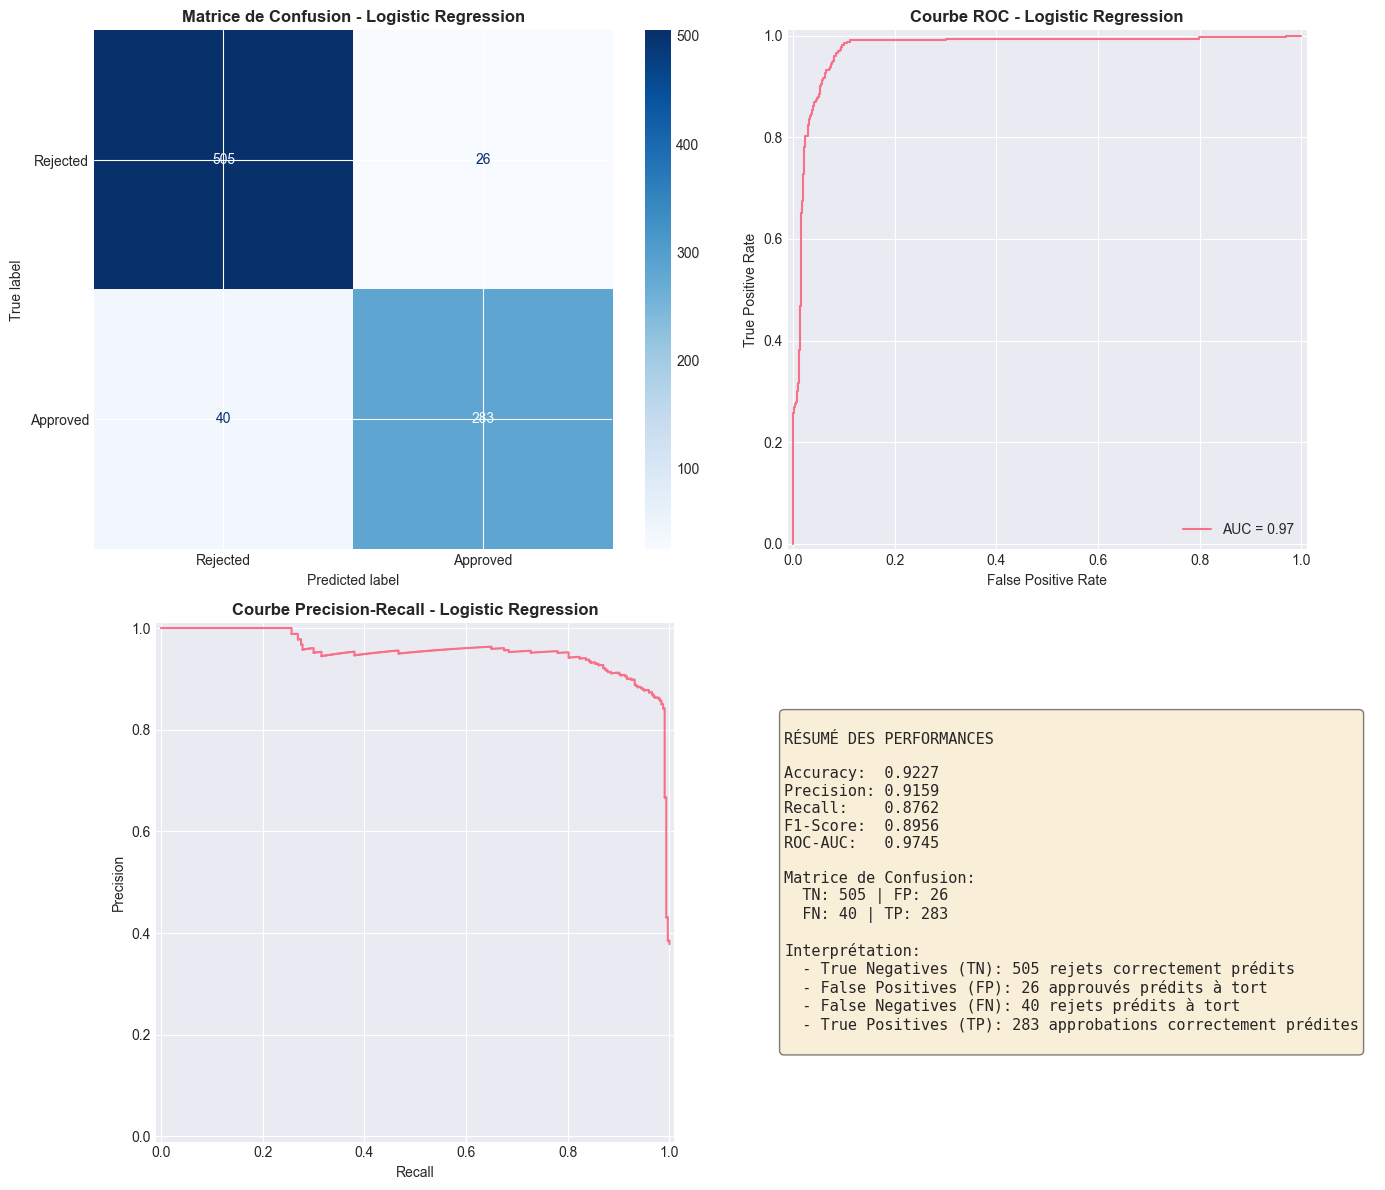

In [10]:
print("=" * 80)
print("ÉVALUATION DU MODÈLE - LOGISTIC REGRESSION")
print("=" * 80)

# Calculer les métriques
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr[:, 1])

print(f"\n📊 MÉTRIQUES DE PERFORMANCE:")
print(f"  Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"  Precision: {precision_lr:.4f} ({precision_lr*100:.2f}%)")
print(f"  Recall:    {recall_lr:.4f} ({recall_lr*100:.2f}%)")
print(f"  F1-Score:  {f1_lr:.4f}")
print(f"  ROC-AUC:   {roc_auc_lr:.4f}")

# Classification Report
print(f"\n📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ:")
print(classification_report(y_test, y_pred_lr, 
                          target_names=['Rejected', 'Approved']))

# Matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Matrice de confusion
ConfusionMatrixDisplay(cm_lr, display_labels=['Rejected', 'Approved']).plot(ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('Matrice de Confusion - Logistic Regression', fontweight='bold')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lr[:, 1])
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_lr).plot(ax=axes[0, 1])
axes[0, 1].set_title('Courbe ROC - Logistic Regression', fontweight='bold')

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_lr[:, 1])
pr_auc = auc(recall_vals, precision_vals)
PrecisionRecallDisplay(precision=precision_vals, recall=recall_vals).plot(ax=axes[1, 0])
axes[1, 0].set_title('Courbe Precision-Recall - Logistic Regression', fontweight='bold')

# Résumé des métriques
metrics_text = f"""
RÉSUMÉ DES PERFORMANCES

Accuracy:  {accuracy_lr:.4f}
Precision: {precision_lr:.4f}
Recall:    {recall_lr:.4f}
F1-Score:  {f1_lr:.4f}
ROC-AUC:   {roc_auc_lr:.4f}

Matrice de Confusion:
  TN: {cm_lr[0,0]} | FP: {cm_lr[0,1]}
  FN: {cm_lr[1,0]} | TP: {cm_lr[1,1]}
  
Interprétation:
  - True Negatives (TN): {cm_lr[0,0]} rejets correctement prédits
  - False Positives (FP): {cm_lr[0,1]} approuvés prédits à tort
  - False Negatives (FN): {cm_lr[1,0]} rejets prédits à tort
  - True Positives (TP): {cm_lr[1,1]} approbations correctement prédites
"""

axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
               verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 10. Comparaison Rapide de Plusieurs Modèles

COMPARAISON DE PLUSIEURS MODÈLES

⏳ Entraînement et évaluation de tous les modèles...

  Entraînement: Logistic Regression... ✓ (Accuracy: 0.9227)
  Entraînement: Random Forest... ✓ (Accuracy: 0.9813)
  Entraînement: Gradient Boosting... ✓ (Accuracy: 0.9836)

📊 TABLEAU COMPARATIF DES MODÈLES
             Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.922717   0.915858 0.876161  0.895570 0.974509
      Random Forest  0.981265   0.993569 0.956656  0.974763 0.996703
  Gradient Boosting  0.983607   0.990476 0.965944  0.978056 0.998391


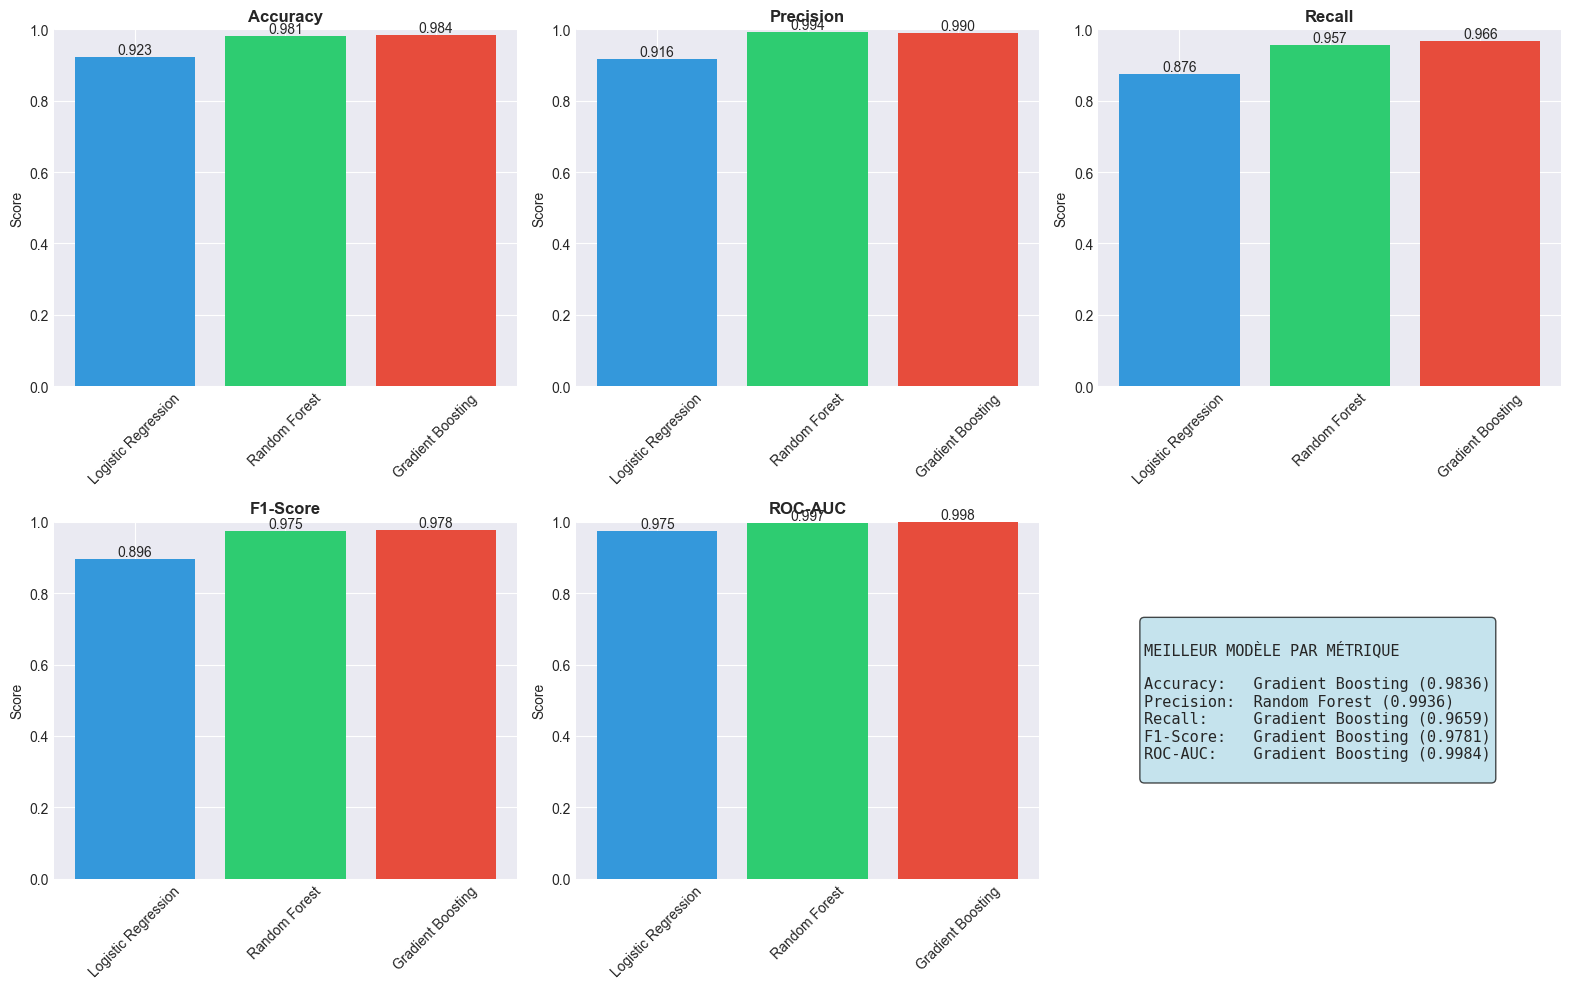


✓ Meilleur modèle sélectionné: Gradient Boosting (F1-Score: 0.9781)


In [11]:
print("=" * 80)
print("COMPARAISON DE PLUSIEURS MODÈLES")
print("=" * 80)

# Dictionnaire des modèles à entraîner
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Stocker les résultats
results = []

print("\n⏳ Entraînement et évaluation de tous les modèles...\n")

for model_name, model in models.items():
    print(f"  Entraînement: {model_name}...", end=" ")
    
    # Créer le pipeline complet
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Entraîner le modèle
    pipeline.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Stocker les résultats
    results.append({
        'Modèle': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Pipeline': pipeline
    })
    
    print(f"✓ (Accuracy: {accuracy:.4f})")

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame(results).drop('Pipeline', axis=1)

print("\n" + "=" * 80)
print("📊 TABLEAU COMPARATIF DES MODÈLES")
print("=" * 80)
print(results_df.to_string(index=False))

# Visualiser la comparaison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, metric in enumerate(metrics):
    values = results_df[metric].values
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    bars = axes[idx].bar(results_df['Modèle'], values, color=colors)
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim([0, 1])
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Ajouter les valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.3f}', ha='center', va='bottom')

# Radar chart ou résumé dans la dernière subplot
axes[5].axis('off')
summary_text = f"""
MEILLEUR MODÈLE PAR MÉTRIQUE

Accuracy:   {results_df.loc[results_df['Accuracy'].idxmax(), 'Modèle']} ({results_df['Accuracy'].max():.4f})
Precision:  {results_df.loc[results_df['Precision'].idxmax(), 'Modèle']} ({results_df['Precision'].max():.4f})
Recall:     {results_df.loc[results_df['Recall'].idxmax(), 'Modèle']} ({results_df['Recall'].max():.4f})
F1-Score:   {results_df.loc[results_df['F1-Score'].idxmax(), 'Modèle']} ({results_df['F1-Score'].max():.4f})
ROC-AUC:    {results_df.loc[results_df['ROC-AUC'].idxmax(), 'Modèle']} ({results_df['ROC-AUC'].max():.4f})
"""
axes[5].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

# Sauvegarder les pipelines pour plus tard
best_model_idx = results_df['F1-Score'].idxmax()
best_pipeline = results[best_model_idx]['Pipeline']
best_model_name = results[best_model_idx]['Modèle']

print(f"\n✓ Meilleur modèle sélectionné: {best_model_name} (F1-Score: {results_df['F1-Score'].max():.4f})")

## 11. Interprétation des Variables Importantes

IMPORTANCE DES VARIABLES

✓ Modèle: Gradient Boosting
✓ Type de classifieur: GradientBoostingClassifier

📊 Utilisation de feature_importances_

🔍 Top 15 features les plus importantes:
                 Feature  Importance
             cibil_score    0.868552
               loan_term    0.096779
             loan_amount    0.016754
            income_annum    0.007637
     luxury_assets_value    0.004720
 commercial_assets_value    0.001923
residential_assets_value    0.001630
        bank_asset_value    0.001305
        no_of_dependents    0.000648
       self_employed_Yes    0.000052
  education_Not Graduate    0.000000


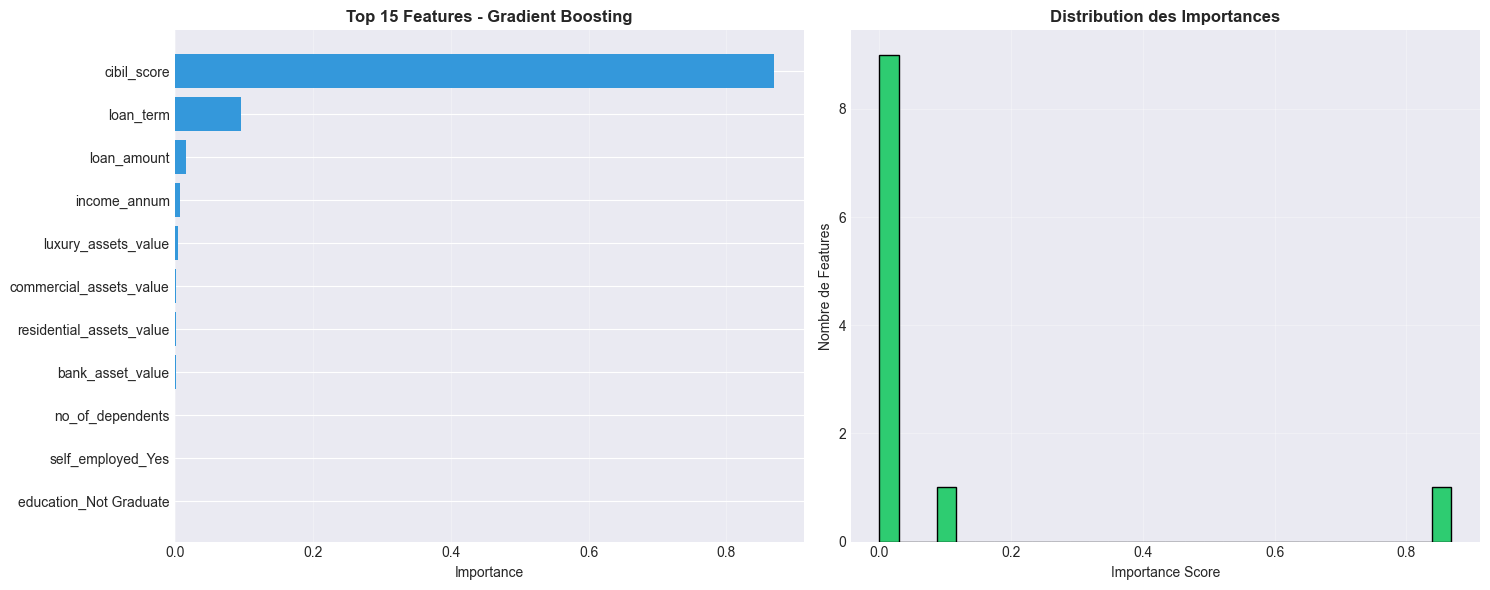

In [12]:
print("=" * 80)
print("IMPORTANCE DES VARIABLES")
print("=" * 80)

# Extraire le meilleur modèle
best_classifier = best_pipeline.named_steps['classifier']

print(f"\n✓ Modèle: {best_model_name}")
print(f"✓ Type de classifieur: {type(best_classifier).__name__}")

# Vérifier si le modèle a feature_importances_
if hasattr(best_classifier, 'feature_importances_'):
    print("\n📊 Utilisation de feature_importances_")
    
    # Récupérer l'ordre des features transformées
    preprocessor = best_pipeline.named_steps['preprocessor']
    
    # Obtenir les noms des features après transformation
    feature_names = []
    
    # Features numériques (juste renommées)
    feature_names.extend(numeric_cols)
    
    # Features catégorielles (une-hot encoded)
    cat_encoder = preprocessor.named_transformers_['cat']
    cat_features = cat_encoder.get_feature_names_out(categorical_cols)
    feature_names.extend(cat_features)
    
    # Importance des features
    importances = best_classifier.feature_importances_
    
    # Créer un DataFrame avec les importances
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\n🔍 Top 15 features les plus importantes:")
    print(importance_df.head(15).to_string(index=False))
    
    # Visualiser
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Top 15
    top_n = 15
    top_features = importance_df.head(top_n)
    
    axes[0].barh(range(len(top_features)), top_features['Importance'].values, color='#3498db')
    axes[0].set_yticks(range(len(top_features)))
    axes[0].set_yticklabels(top_features['Feature'].values)
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Importance')
    axes[0].set_title(f'Top {top_n} Features - {best_model_name}', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Distribution des importances
    axes[1].hist(importance_df['Importance'], bins=30, color='#2ecc71', edgecolor='black')
    axes[1].set_xlabel('Importance Score')
    axes[1].set_ylabel('Nombre de Features')
    axes[1].set_title('Distribution des Importances', fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

elif hasattr(best_classifier, 'coef_'):
    print("\n📊 Utilisation des coefficients (Logistic Regression)")
    
    # Pour LogisticRegression
    coef = best_classifier.coef_[0]
    
    # Même chose pour les features
    feature_names = []
    feature_names.extend(numeric_cols)
    
    cat_encoder = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_features = cat_encoder.get_feature_names_out(categorical_cols)
    feature_names.extend(cat_features)
    
    # Créer un DataFrame
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'Abs_Coefficient': np.abs(coef)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print(f"\n🔍 Top 15 features les plus influentes:")
    print(coef_df[['Feature', 'Coefficient']].head(15).to_string(index=False))
    
    # Visualiser
    fig, ax = plt.subplots(figsize=(12, 8))
    
    top_n = 15
    top_coef = coef_df.head(top_n)
    
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_coef['Coefficient']]
    ax.barh(range(len(top_coef)), top_coef['Coefficient'].values, color=colors)
    ax.set_yticks(range(len(top_coef)))
    ax.set_yticklabels(top_coef['Feature'].values)
    ax.invert_yaxis()
    ax.set_xlabel('Coefficient')
    ax.set_title(f'Top {top_n} Features - Impact sur la Prédiction (Logistic Regression)', fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    
    # Légende
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ecc71', label='Augmente probabilité d\'approbation'),
                       Patch(facecolor='#e74c3c', label='Diminue probabilité d\'approbation')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.show()

## 12. Sauvegarde du Pipeline et Prédiction sur Nouveaux Cas

SAUVEGARDE DU MEILLEUR PIPELINE

✓ Pipeline sauvegardé: meilleur_pipeline_approbation_pret.pkl
  Modèle: Gradient Boosting
  Taille du fichier: 140.72 KB
✓ Label Encoder sauvegardé: label_encoder_loan_status.pkl

PRÉDICTIONS SUR DE NOUVEAUX CAS

📋 PRÉDICTIONS POUR 3 NOUVEAUX DEMANDEURS:

Demandeur #1:
  Revenu annuel: $10,000,000
  Montant du prêt: $30,000,000
  Score CIBIL: 750
  Éducation: Graduate
  Travailleur indépendant: No

  ➜ PRÉDICTION: Approved
  Probabilité Approved: 0.25%
  Probabilité Rejected: 99.75%
  Confiance: 99.75%

Demandeur #2:
  Revenu annuel: $1,000,000
  Montant du prêt: $5,000,000
  Score CIBIL: 350
  Éducation: Not Graduate
  Travailleur indépendant: Yes

  ➜ PRÉDICTION: Rejected
  Probabilité Approved: 99.27%
  Probabilité Rejected: 0.73%
  Confiance: 99.27%

Demandeur #3:
  Revenu annuel: $5,000,000
  Montant du prêt: $15,000,000
  Score CIBIL: 550
  Éducation: Graduate
  Travailleur indépendant: Yes

  ➜ PRÉDICTION: Approved
  Probabilité Approved: 0.19%
 

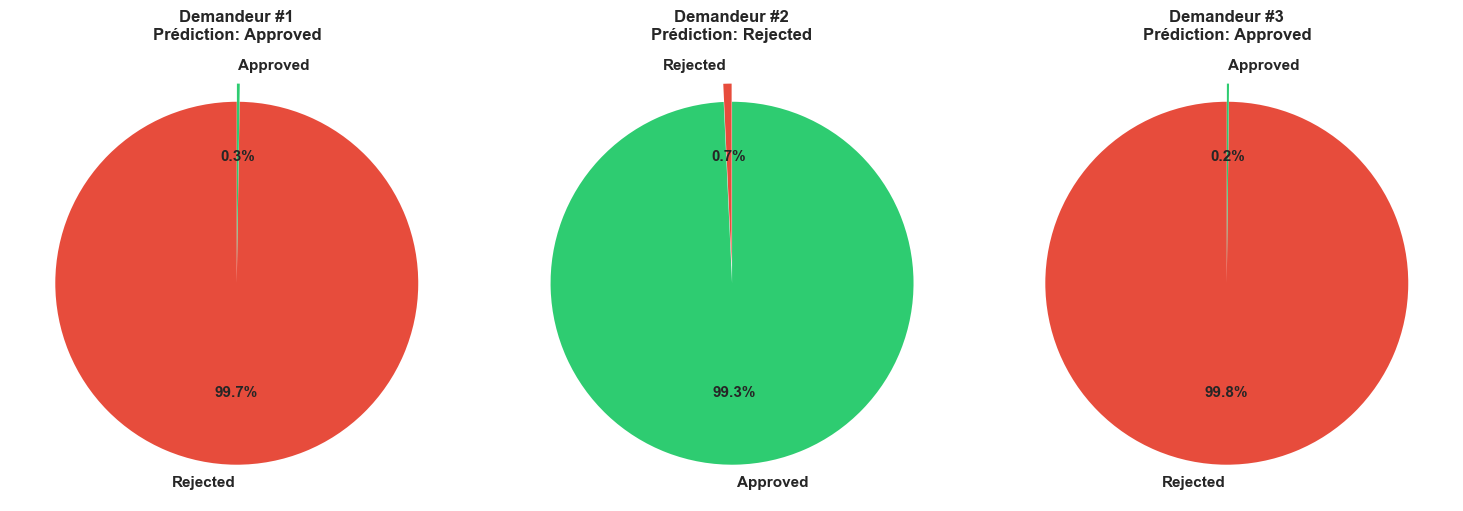

✓ ANALYSE TERMINÉE AVEC SUCCÈS!


In [13]:
print("=" * 80)
print("SAUVEGARDE DU MEILLEUR PIPELINE")
print("=" * 80)

# Sauvegarder le pipeline
model_path = "meilleur_pipeline_approbation_pret.pkl"
joblib.dump(best_pipeline, model_path)

print(f"\n✓ Pipeline sauvegardé: {model_path}")
print(f"  Modèle: {best_model_name}")
print(f"  Taille du fichier: {os.path.getsize(model_path) / 1024:.2f} KB")

# Sauvegarder aussi le label encoder pour la variable cible
joblib.dump(label_encoder, "label_encoder_loan_status.pkl")
print(f"✓ Label Encoder sauvegardé: label_encoder_loan_status.pkl")

print("\n" + "=" * 80)
print("PRÉDICTIONS SUR DE NOUVEAUX CAS")
print("=" * 80)

# Exemple 1: Un demandeur avec bonnes caractéristiques (probablement approuvé)
new_applicant_1 = pd.DataFrame({
    'no_of_dependents': [2],
    'education': ['Graduate'],
    'self_employed': ['No'],
    'income_annum': [10000000],  # 10 millions
    'loan_amount': [30000000],   # 30 millions
    'loan_term': [12],
    'cibil_score': [750],
    'residential_assets_value': [10000000],
    'commercial_assets_value': [5000000],
    'luxury_assets_value': [15000000],
    'bank_asset_value': [8000000]
})

# Exemple 2: Un demandeur avec caractéristiques faibles (probablement rejeté)
new_applicant_2 = pd.DataFrame({
    'no_of_dependents': [5],
    'education': ['Not Graduate'],
    'self_employed': ['Yes'],
    'income_annum': [1000000],   # 1 million
    'loan_amount': [5000000],    # 5 millions
    'loan_term': [20],
    'cibil_score': [350],
    'residential_assets_value': [500000],
    'commercial_assets_value': [100000],
    'luxury_assets_value': [300000],
    'bank_asset_value': [200000]
})

# Exemple 3: Cas moyen
new_applicant_3 = pd.DataFrame({
    'no_of_dependents': [3],
    'education': ['Graduate'],
    'self_employed': ['Yes'],
    'income_annum': [5000000],   # 5 millions
    'loan_amount': [15000000],   # 15 millions
    'loan_term': [10],
    'cibil_score': [550],
    'residential_assets_value': [5000000],
    'commercial_assets_value': [2000000],
    'luxury_assets_value': [8000000],
    'bank_asset_value': [4000000]
})

# Combiner les nouveaux demandeurs
new_applicants = pd.concat([new_applicant_1, new_applicant_2, new_applicant_3], 
                            ignore_index=True)

# Faire les prédictions
predictions = best_pipeline.predict(new_applicants)
probabilities = best_pipeline.predict_proba(new_applicants)

print(f"\n📋 PRÉDICTIONS POUR 3 NOUVEAUX DEMANDEURS:\n")

for i in range(len(new_applicants)):
    predicted_class = label_encoder.inverse_transform([predictions[i]])[0]
    prob_rejected = probabilities[i][0]
    prob_approved = probabilities[i][1]
    confidence = max(prob_rejected, prob_approved) * 100
    
    print(f"Demandeur #{i+1}:")
    print(f"  Revenu annuel: ${new_applicants.iloc[i]['income_annum']:,.0f}")
    print(f"  Montant du prêt: ${new_applicants.iloc[i]['loan_amount']:,.0f}")
    print(f"  Score CIBIL: {new_applicants.iloc[i]['cibil_score']:.0f}")
    print(f"  Éducation: {new_applicants.iloc[i]['education']}")
    print(f"  Travailleur indépendant: {new_applicants.iloc[i]['self_employed']}")
    print(f"\n  ➜ PRÉDICTION: {predicted_class}")
    print(f"  Probabilité Approved: {prob_approved*100:.2f}%")
    print(f"  Probabilité Rejected: {prob_rejected*100:.2f}%")
    print(f"  Confiance: {confidence:.2f}%")
    print()

# Créer une visualisation des prédictions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    labels = ['Rejected', 'Approved']
    sizes = [probabilities[i][0], probabilities[i][1]]
    colors = ['#e74c3c', '#2ecc71']
    explode = (0.05, 0.05)
    
    axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
               explode=explode, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
    
    predicted_class = label_encoder.inverse_transform([predictions[i]])[0]
    axes[i].set_title(f'Demandeur #{i+1}\nPrédiction: {predicted_class}', 
                     fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 80)
print("✓ ANALYSE TERMINÉE AVEC SUCCÈS!")
print("=" * 80)